In [44]:
import numpy as np
import astropy.units as u
from specutils import Spectrum1D
from specutils.analysis import correlation
from astropy.nddata import StdDevUncertainty
import os, sys
from astropy.io import fits, ascii
%matplotlib notebook
import matplotlib.pyplot as plt
from ipywidgets import interact
import importlib
import copy
import warnings
import copy
from scipy import interpolate

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [3]:
sys.path.insert(0,'../../interface/')
import GISIC_C as GISIC


In [26]:
spectra_path= "../../inputs/spectra/bf-full-survey-data/"
star_name = "g77-61"

spec2 = fits.open(spectra_path+star_name+"_m2b_casper.fits")
spec1 = fits.open(spectra_path+star_name+"_m1b_casper.fits")

In [53]:
spec2.info()

Filename: ../../inputs/spectra/bf-full-survey-data/g77-61_m2b_casper.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     287   (8192, 1, 4)   float32   


In [27]:
wave1= (np.arange(0, spec1[0].header['NAXIS1'], 1) * spec1[0].header['CD1_1']) + spec1[0].header['CRVAL1']
flux1 =  spec1[0].data[0].flatten()
wave2= (np.arange(0, spec2[0].header['NAXIS1'], 1) * spec2[0].header['CD1_1']) + spec2[0].header['CRVAL1']
flux2 =  spec2[0].data[0].flatten()

In [28]:
len(wave1), len(flux1)
len(wave2), len(flux2)
wave1[1]-wave1[0]
wave2[1]-wave2[0]

(8192, 8192)

(8192, 8192)

0.5374806452105076

0.5486290983708386

In [29]:
# For two spectra having different sized arrays, we need to reframe the arrays. 
# To do so, we redefine the wavelength range and interpolate flux based on the new wave array.

In [30]:
wave = np.arange(3250, 5500, 0.55)
reframe_intp1= interpolate.interp1d(wave1,flux1, kind='cubic' )
reframe_intp2= interpolate.interp1d(wave2,flux2, kind='cubic' )

reflux1 = reframe_intp1(wave)
reflux2 = reframe_intp2(wave)


<IPython.core.display.Javascript object>


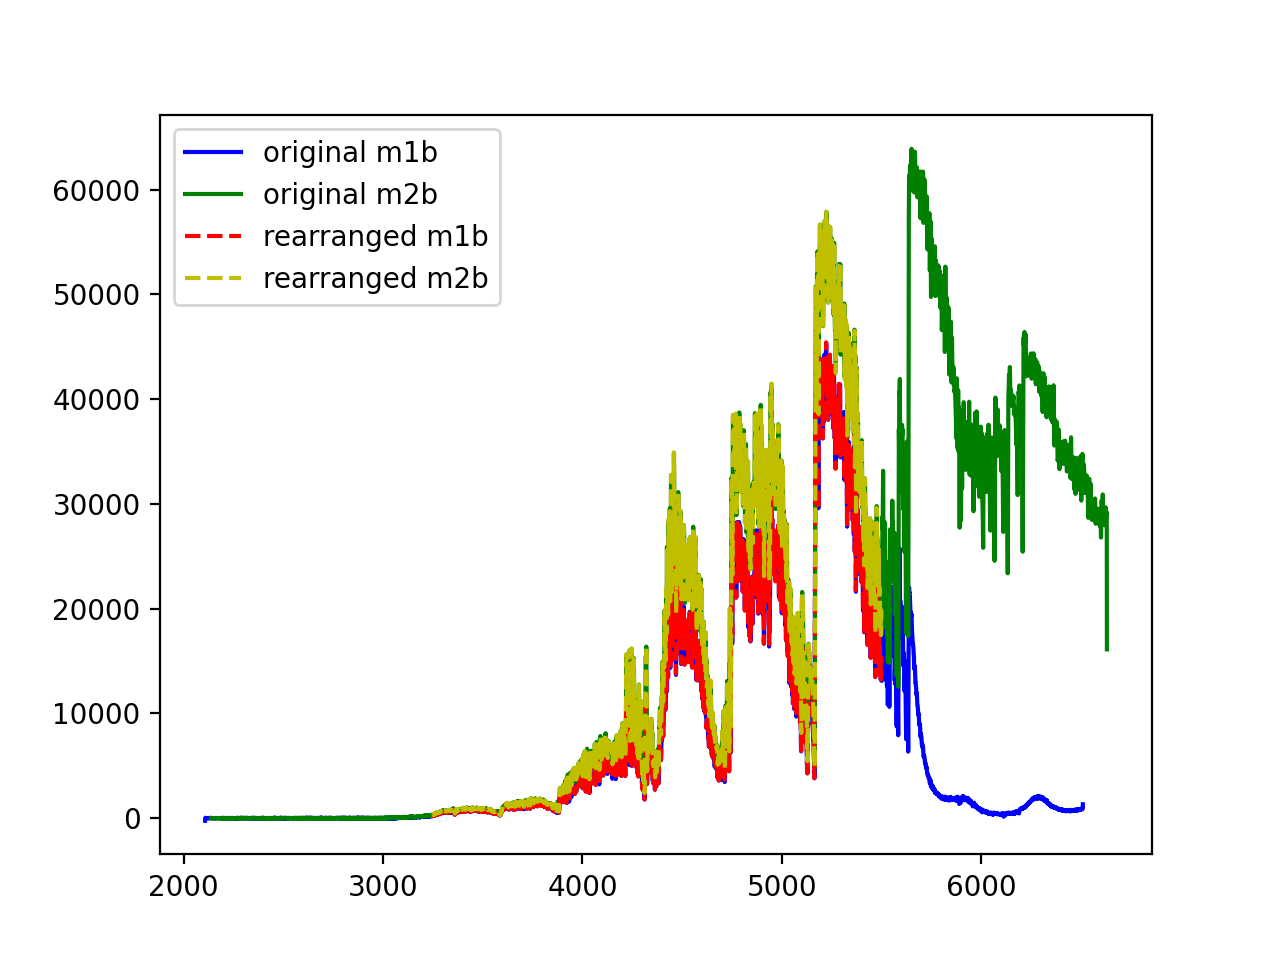

In [31]:
plt.plot(wave1, flux1, color='b', label='original m1b')
plt.plot(wave2, flux2, color='g', label='original m2b')
plt.plot(wave, reflux1, 'r--', label='rearranged m1b')
plt.plot(wave, reflux2, 'y--', label= 'rearranged m2b')
plt.legend()

In [32]:
#importlib.reload(GISIC)
wave, norm_flux1, continuum1 = GISIC.normalize(wave, reflux1, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=True)
wave, norm_flux2, continuum2 = GISIC.normalize(wave, reflux2, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=True)


	adding CaII H&K continuum points
	adding CaII H&K continuum points


../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=Tr

<IPython.core.display.Javascript object>


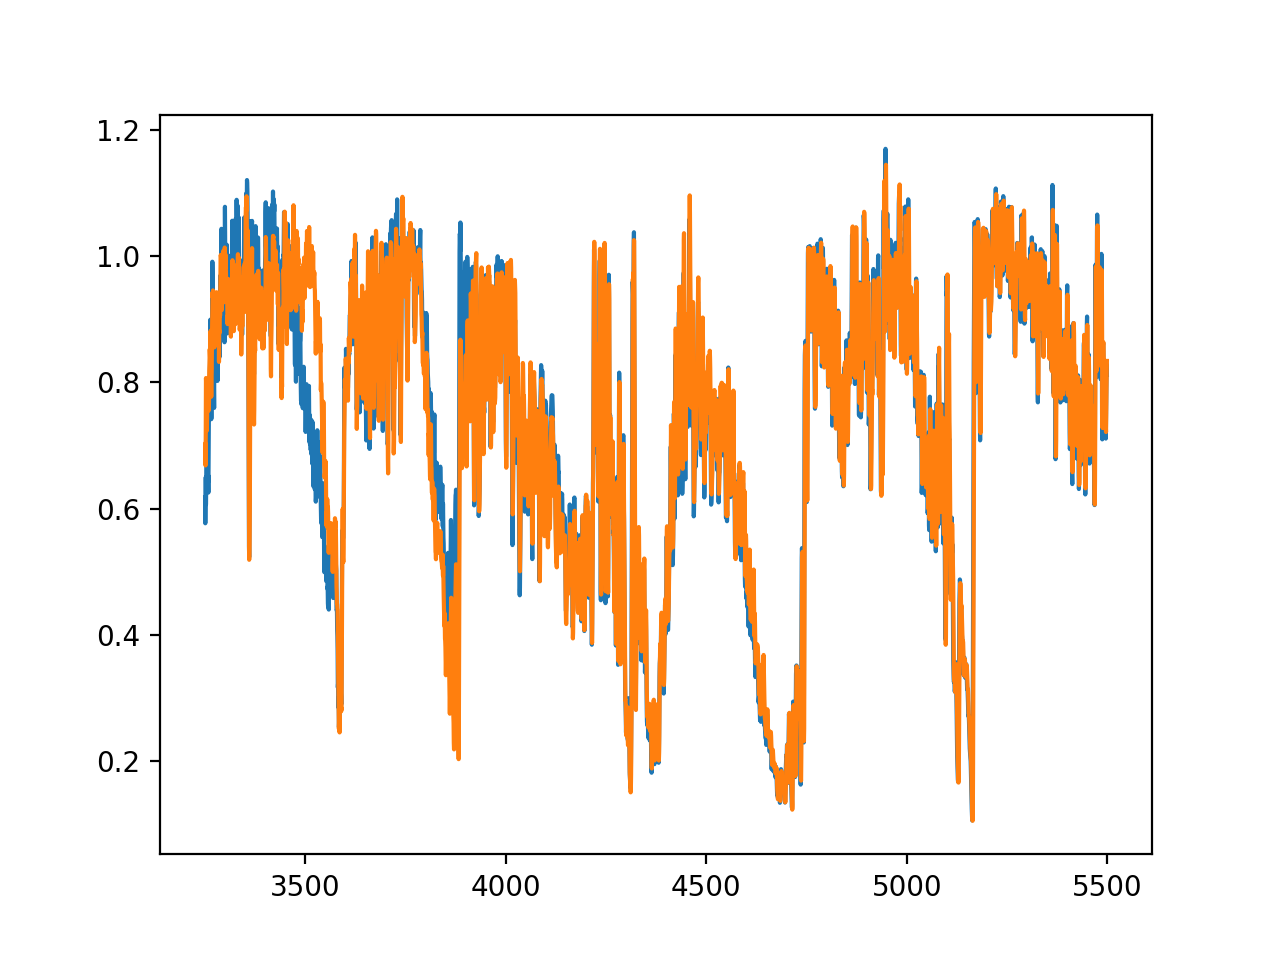

4091
4091
4091


In [33]:
plt.plot(wave, norm_flux1)
plt.plot(wave, norm_flux2)

print((len(wave)))
print(len(norm_flux1))
print(len(norm_flux2))

In [34]:
uncertainty = StdDevUncertainty(0.1*np.ones(len(wave))*u.photon)


In [54]:
#spec1_utils = Spectrum1D(spectral_axis=wave*u.AA, flux=norm_flux1*u.photon,uncertainty=uncertainty, velocity_convention='optical', rest_value=4320. *u.AA)
#spec2_utils = Spectrum1D(spectral_axis=wave*u.AA, flux=norm_flux2*u.photon,uncertainty=uncertainty, velocity_convention='optical')

spec1_utils = Spectrum1D(spectral_axis=wave*u.AA, flux=reflux1*u.photon,uncertainty=uncertainty, velocity_convention='optical', rest_value=4320. *u.AA)
spec2_utils = Spectrum1D(spectral_axis=wave*u.AA, flux=reflux2*u.photon,uncertainty=uncertainty, velocity_convention='optical')


In [55]:
spec1_trim= spec1_utils[3700*u.AA:5000*u.AA]
spec2_trim= spec2_utils[3700*u.AA:5000*u.AA]

<IPython.core.display.Javascript object>


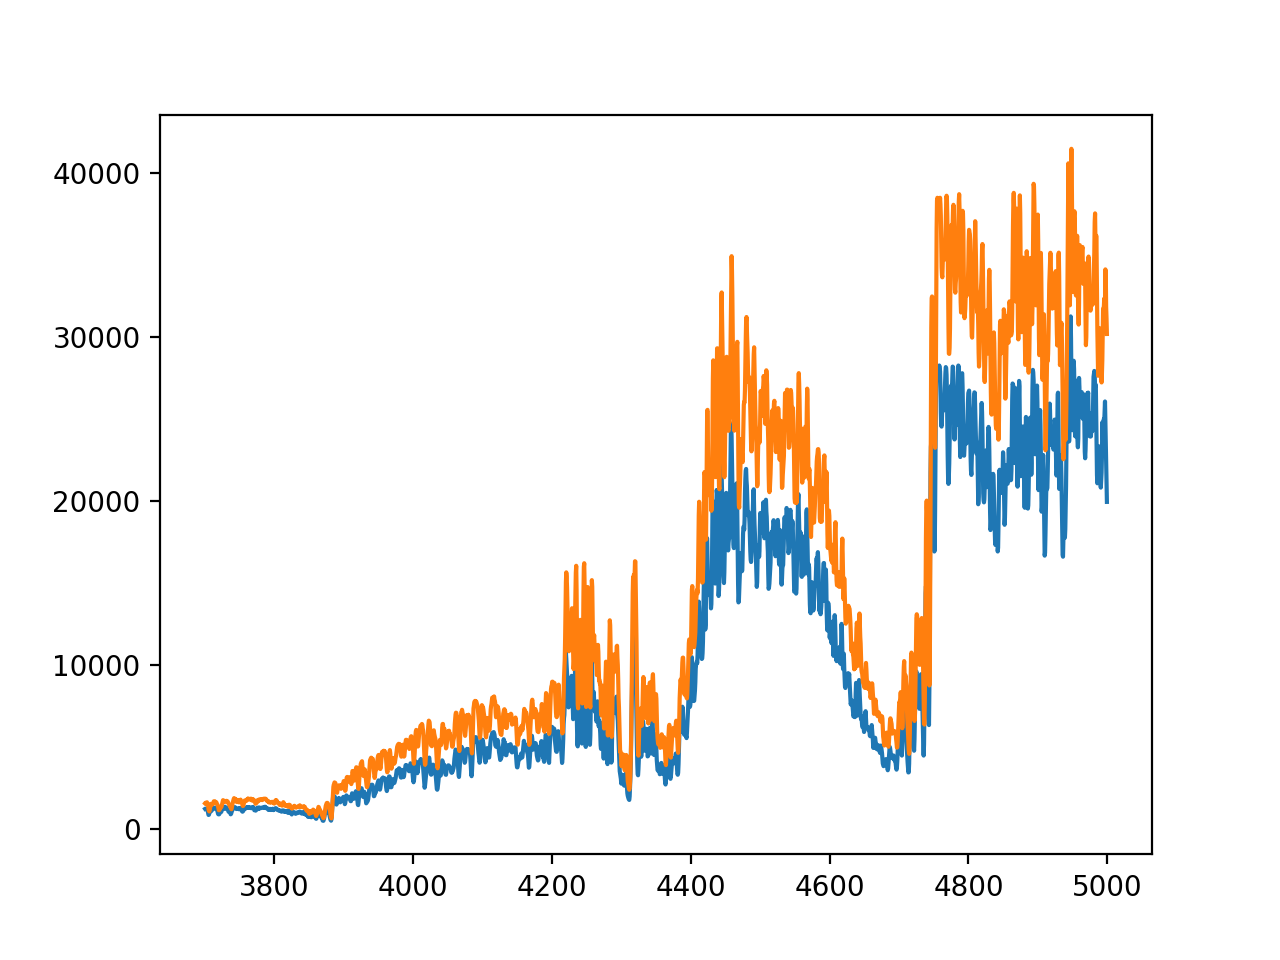

In [56]:
plt.plot(spec1_trim.spectral_axis, spec1_trim.flux)
plt.plot(spec2_trim.spectral_axis, spec2_trim.flux)

In [57]:
spec1_trim.spectral_axis
spec2_trim.spectral_axis
len(spec1_trim.spectral_axis)
len(spec2_trim.spectral_axis)

<SpectralAxis 
   (doppler_rest=4320.0 Angstrom
    doppler_convention=optical)
  [3700.45, 3701.  , 3701.55, ..., 4998.45, 4999.  , 4999.55] Angstrom>

<SpectralAxis 
   (doppler_rest=None
    doppler_convention=optical)
  [3700.45, 3701.  , 3701.55, ..., 4998.45, 4999.  , 4999.55] Angstrom>

2363

2363

In [58]:
# uncertainty calculation
# this value can be used in Spectrum1D for cross-correlation below.
from specutils import SpectralRegion
from specutils.manipulation import noise_region_uncertainty
noise_region = SpectralRegion([(3900, 3920), (4530, 4550)] * u.AA)
spec_w_unc = noise_region_uncertainty(spec1_utils, noise_region)
spec_w_unc.uncertainty 

StdDevUncertainty([7907.67860993, 7907.67860993, 7907.67860993, ...,
                   7907.67860993, 7907.67860993, 7907.67860993])

In [59]:
with warnings.catch_warnings():  # Ignore warnings
    warnings.simplefilter('ignore')
    corr, lag = correlation.template_correlate(spec1_trim, spec2_trim)

In [60]:
corr
lag
lag.unit
maxind = np.argmax(corr)
print(lag[maxind].value)
print(corr[maxind])
print(type(lag[maxind].value))

<Quantity [0.        , 0.        , 0.00085537, ..., 0.00075633, 0.        ,
           0.        ]>

<Quantity [-77850.29284578, -77825.87432391, -77801.45311546, ...,
           105068.62148576, 105113.16511323, 105157.71364148] km / s>

Unit("km / s")

-32.98013859219813
202444725551.06897
<class 'numpy.float64'>


In [61]:
spec2_shift= copy.deepcopy(spec2_trim)
spec2_trim.spectral_axis
spec2_shift.shift_spectrum_to(radial_velocity = lag[maxind])
spec2_shift.spectral_axis

spec2_trim.spectral_axis-spec2_shift.spectral_axis

<SpectralAxis 
   (doppler_rest=None
    doppler_convention=optical)
  [3700.45, 3701.  , 3701.55, ..., 4998.45, 4999.  , 4999.55] Angstrom>

<SpectralAxis 
   (observer to target:
      radial_velocity=-32.98013859219813 km / s
      redshift=-0.00011000385046666672
    doppler_rest=None
    doppler_convention=optical)
  [3700.04293625, 3700.59287575, 3701.14281525, ..., 4997.90015125,
   4998.45009075, 4999.00003025] Angstrom>

<Quantity [0.40706375, 0.40712425, 0.40718475, ..., 0.54984875, 0.54990925,
           0.54996975] Angstrom>

<IPython.core.display.Javascript object>


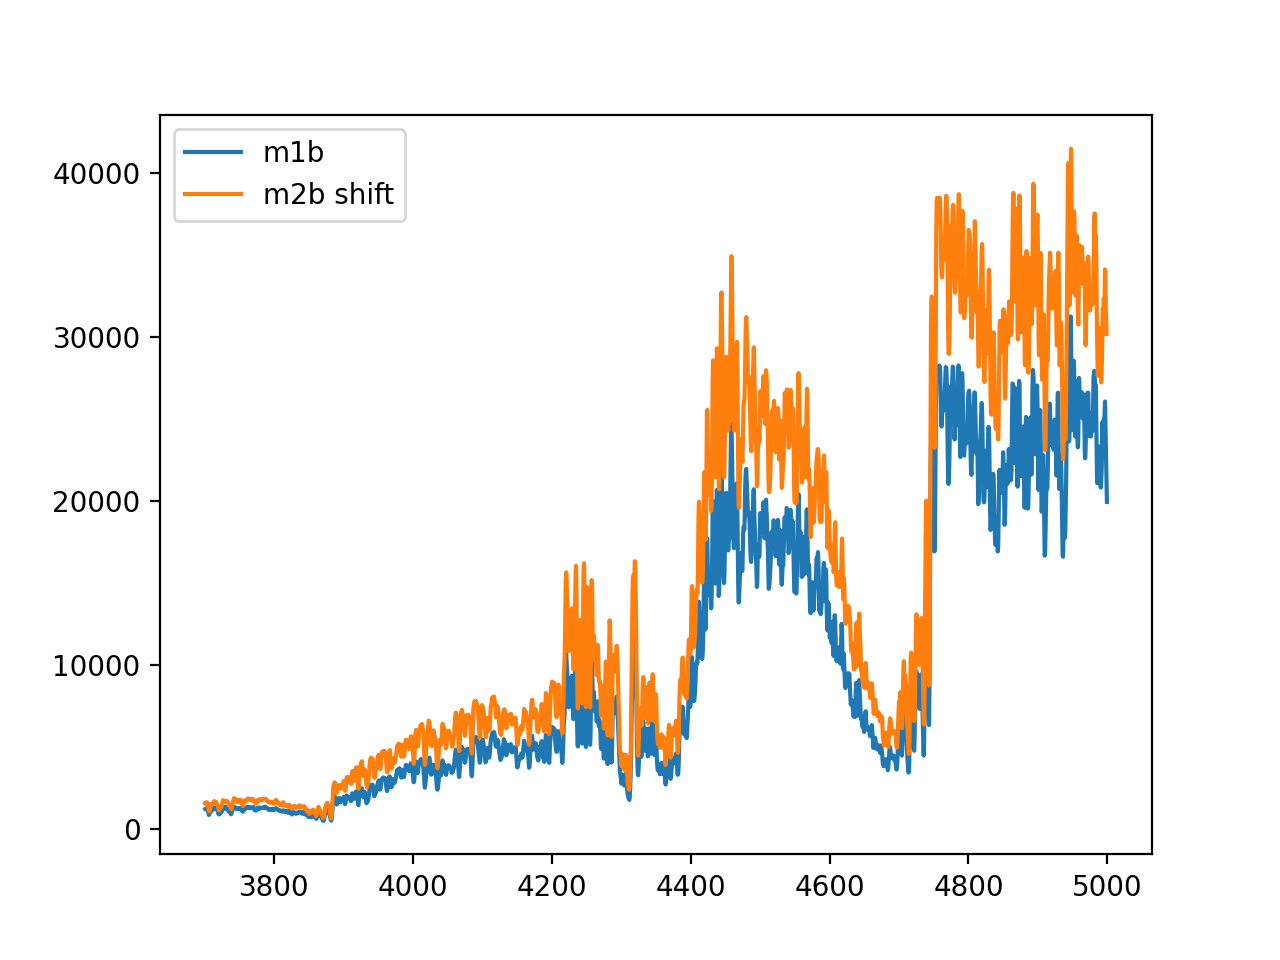

In [63]:
plt.plot(spec1_trim.spectral_axis, spec1_trim.flux, label='m1b')
#plt.plot(spec2_trim.spectral_axis, spec2_trim.flux, label='m2b')
plt.plot(spec2_shift.spectral_axis, spec2_shift.flux, label='m2b shift')
plt.legend()

In [ ]:
'''
from astropy.constants import si

RV_shift=lag[maxind]
new_wave= spec1_trim.spectral_axis* (RV_shift/(si.c.to(u.Unit("km/s")))+ 1)


#speed of light cm/s to km/s
si.c.to(u.km/u.s)
'''

In [ ]:
'''
from specutils.manipulation import LinearInterpolatedResampler
new_spec1 = LinearInterpolatedResampler(spec1_trim, new_wave ) 
new_spec2 = LinearInterpolatedResampler(spec2_shift, new_wave )  
'''

In [ ]:
'''
# interpolation method from PyAstronomy
# however, I'd better use scipy.interp1d() for the long term use.
from PyAstronomy import pyasl

x = np.arange(10.)
y = np.sin(x/5.*2.*np.pi)

# Choose the values at which to interpolate
xx = np.arange(120.)/10.-2.0
# Interpolate and suppress the exception that
# would indicate that some of our requested
# values (xx) are beyond the range covered by x.
yy = pyasl.intep(x, y, xx, boundsError=False)
# Plot the result
plt.plot(x, y, 'bp')
plt.plot(xx, yy, 'r--')
plt.show()
'''

In [64]:
new_wave = np.arange(3750, 4950, 0.55) * u.AA

In [65]:
fct_intp1= interpolate.interp1d(spec1_trim.spectral_axis.value, spec1_trim.flux.value, kind = 'cubic')
fct_intp2= interpolate.interp1d(spec2_shift.spectral_axis.value, spec2_shift.flux.value, kind = 'cubic')

In [66]:
new_flux1 = fct_intp1(new_wave)
new_flux2 = fct_intp2(new_wave)

coadd_flux = (new_flux1+new_flux2)

new_wave, norm_coadd_flux, continuum_coadd = GISIC.normalize(new_wave, coadd_flux, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=True)

new_wave, norm_coadd_flux2, continuum_coadd = GISIC.normalize(new_wave, norm_coadd_flux, sigma=30, k=1, 
                                                cahk=True,band_check=True, boost=True)



	adding CaII H&K continuum points
	adding CaII H&K continuum points


../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=True)].copy()
../../interface/GISIC_C/spectrum.py:94: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  SEGMENT = self.frame[self.frame['wave'].between(self.ZEROS[i], self.ZEROS[i+1], inclusive=Tr

<IPython.core.display.Javascript object>


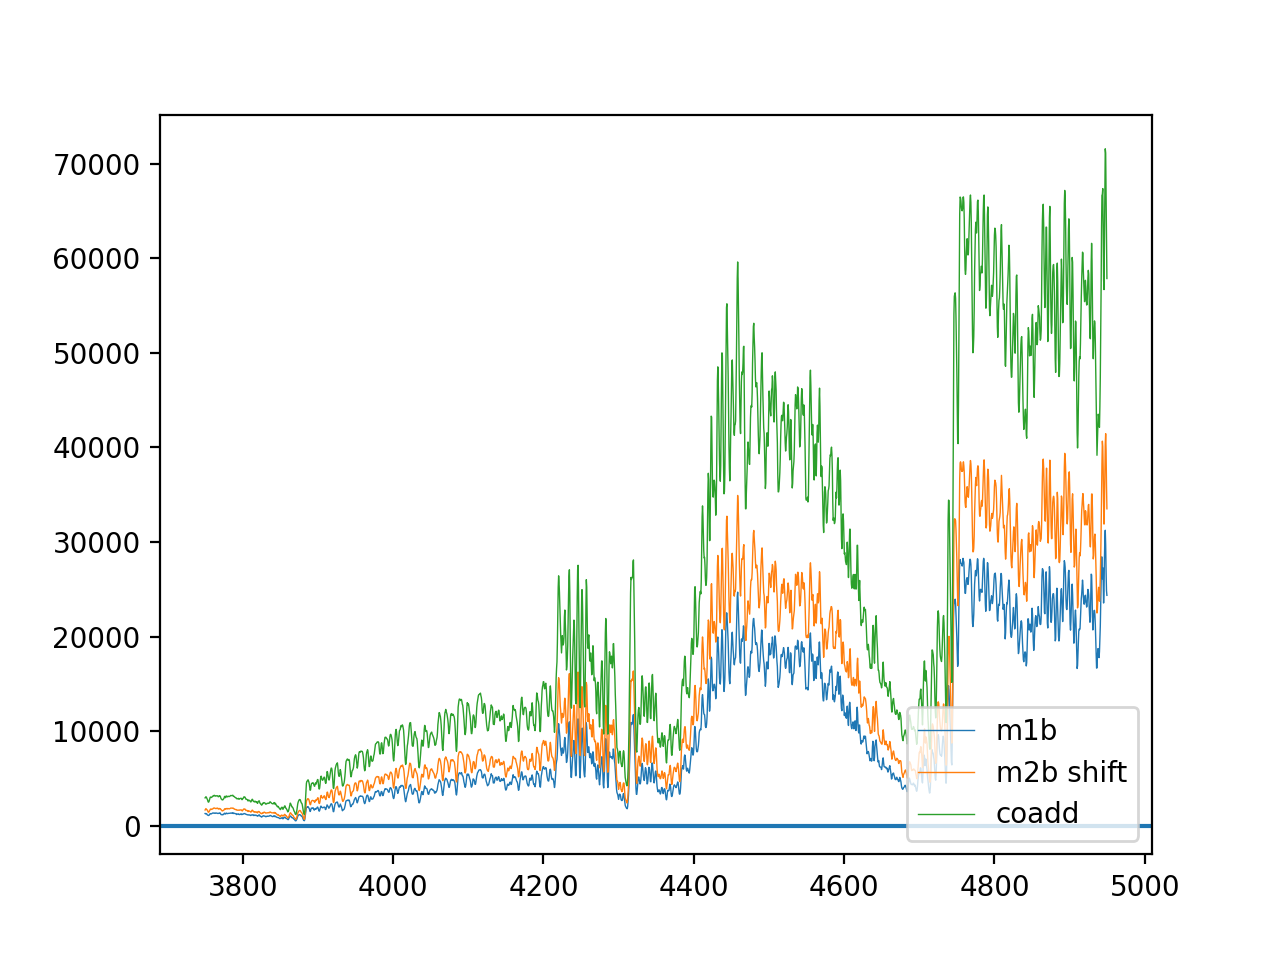

In [72]:
plt.plot(new_wave, new_flux1,lw= 0.5, label='m1b')
plt.plot(new_wave, new_flux2,lw= 0.5, label='m2b shift')
plt.plot(new_wave, coadd_flux,lw= 0.5, label= "coadd")
#plt.plot(new_wave, norm_coadd_flux, lw= 0.5, label ='GISIC coadd')
#plt.plot(new_wave, norm_coadd_flux2, lw=0.5, label ='2*GISIC coadd')
plt.axhline(1)
plt.legend(loc=4)

In [ ]:
ascii.write(new_wave, coadd_flux, star_name+"coadd.csv", format='csv')
ascii.write(new_wave, norm_coadd_flux, star_name+"coadd_norm.csv", format='csv')